<a href="https://colab.research.google.com/github/mugalan/introduction-to-statistical-learning/blob/main/review_of_probability_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reference

This content is based on the excellent teaching material of [Probability Theory Autumn 2023 by Igor Kortchemski](https://metaphor.ethz.ch/x/2023/hs/401-3601-00L/#lecturenotes)

# 1. Foundations of Probability Spaces

The notion of **probability** quantifies the **likelihood** of an **event occurring**, interpreted either as a long-run frequency or as a degree of belief based on available information.

In measure theory, we treat the sample space $\Omega$ as the "universal set" where every probabilistic outcome is a point $\omega\in \Omega$.

> **An Event is a Subset.**
> If $\Omega$ is the universe of "what could happen," then an **event $A$** is simply a collection of specific outcomes, making $A$ a **subset** of $\Omega$ ($A \subseteq \Omega$).

 Consequently, logical operations on events translate directly into set operations on subsets: the occurrence of **"A or B"** is the **union** ($A \cup B$), **"A and B"** is the **intersection** ($A \cap B$), and **"not A"** is the **complement** ($A^c$). Under this mapping, the probability $P(A)$ is simply the "size" or **measure** of the subset $A$ relative to the total measure of the universe $\Omega$.

In the following we formalize these notions in a concrete way.

## 1.1 $\sigma$-algebras

### 1.1.1 The Need for $\sigma$-algebras

In elementary probability (like coin flips or dice rolls), $\Omega$ is finite. In these cases, our intuition tells us that every imaginable collection of outcomes should have a probability. However this is not true of infinite sample spaces. For example the **Vitali Paradox** proves that if there exist "pathological" subsets that are so fragmented and irregular they have no "length" or "volume." Thus if we try to assign a probability to these specific subsets, we break the **Axiom of Countable Additivity** (the rule that the probability of a union of disjoint events must equal the sum of their individual probabilities). To resolve this, we restrict our attention to a collection of "well-behaved" subsets called a **$\sigma$-algebra**.


In essence, a $\sigma$-algebra represents "**available information**" because its granularity determines which events we can actually distinguish.

If a specific subset is not in our $\sigma$-algebra, our "information set" is too coarse to determine whether that event occurred, effectively treating its internal details as unobservable noise.

A smaller $\sigma$-algebra means you have less "resolution" or "granularity" regarding the outcome.

### 1.1.2 Definition: $\sigma$-algebra



Let $\Omega$ be a non-empty set (the sample space). A collection $\mathfrak{F}$ of subsets of $\Omega$ is called a **$\sigma$-algebra** if it satisfies the following three axioms:

1. **Contains the empty set:**

$$\emptyset \in \mathfrak{F}$$


2. **Closed under complementation:**
If $A \in \mathfrak{F}$, then $A^c \in \mathfrak{F}$
*(If we can measure the probability of an event happening, we must be able to measure the probability of it not happening.)*
3. **Closed under countable unions:**
If $A_1, A_2, A_3, \dots \in \mathfrak{F}$, then $\bigcup_{n=1}^{\infty} A_n \in \mathfrak{F}$
*(This is the critical "measure-theoretic" leap from finite to infinite processes, allowing us to handle limits.)*



#### Key Consequences

From these axioms, it follows that a $\sigma$-algebra is also closed under **countable intersections**:


$$\bigcap_{n=1}^{\infty} A_n = \left( \bigcup_{n=1}^{\infty} A_n^c \right)^c \in \mathfrak{F}$$



#### Numerical Intuition: Simulating the Breakdown

While we cannot "code" an infinite $\sigma$-algebra, we can demonstrate the property of **stability under operations**.


In [ ]:
# Example: Checking if a collection of sets is closed under union (Finite case)
sample_space = {1, 2, 3, 4}
sigma_algebra = [set(), {1, 2}, {3, 4}, {1, 2, 3, 4}]

def is_closed_under_union(collection):
    for a in collection:
        for b in collection:
            if a.union(b) not in collection:
                return False
    return True

print(f"Is the collection closed under union? {is_closed_under_union(sigma_algebra)}")

#### Example #1: The Borel $\sigma$-algebra $\mathfrak{B}(\mathbb{R})$

We often work with $\Omega = \mathbb{R}$. The most important $\sigma$-algebra for the real line is the **Borel $\sigma$-algebra**, denoted $\mathfrak{B}(\mathbb{R})$. It is defined as the smallest $\sigma$-algebra containing all open intervals $(a, b)$.

Almost any set you can "describe" or "construct" (intervals, points, open sets, closed sets) is a Borel set.



#### Example #2: The Trivial $\sigma$-algebra

The smallest possible $\sigma$-algebra for any $\Omega$ is the **Trivial $\sigma$-algebra**:


$$\mathfrak{F}_{trivial} = \{ \emptyset, \Omega \}$$


In this case, you can only measure the probability of "nothing happening" ($\emptyset$) or "something happening" ($\Omega$).

#### Example #4: The Power Set

The **Power Set** of a set $\Omega$ is the collection of all possible subsets of $\Omega$, including the empty set and $\Omega$ itself.


Let $\Omega$ be any set. The power set, denoted by $\mathfrak{P}(\Omega)$ or $2^\Omega$, is defined as:


$$\mathfrak{P}(\Omega) = \{ A : A \subseteq \Omega \}$$

---

**Key Properties**

1. **Cardinality:** If a finite set $\Omega$ has $n$ elements, the power set $\mathfrak{P}(\Omega)$ has $2^n$ elements.
* *This is why the notation $2^\Omega$ is often used.*


2. **The "Largest" $\sigma$-algebra:** For any sample space $\Omega$, the power set is the most granular $\sigma$-algebra possible. It allows us to assign a probability to every single individual outcome and every combination of outcomes.

---

**Why is it important in Statistical Learning?**

In many machine learning applications involving discrete features (like "Heads/Tails," "Spam/Not Spam," or "Class A/B/C"), we assume the $\sigma$-algebra is the **power set**. This is because we have no mathematical restriction preventing us from measuring the probability of any specific subset of these discrete outcomes.

---

**Important Note**

While the Power Set works perfectly for finite sets, we **cannot** use the Power Set of the Real Numbers ($\mathbb{R}$) as our $\sigma$-algebra for continuous probability. The Power Set of $\mathbb{R}$ is "too big" and contains sets that are impossible to measure (Non-measurable sets), which is why we must use the **Borel $\sigma$-algebra** instead.

#### Example #5: Multiple $\sigma$-algebras on the Same Space

Consider the sample space of a fair die roll:


$$\Omega = \{1, 2, 3, 4, 5, 6\}$$

We can define two different "observers" who have access to different levels of information about the result.

**Observer A:** "The Odd/Even Observer"

This observer only cares (or is only told) if the result was even or odd. They cannot distinguish between a $2$ and a $4$, but they can distinguish between a $2$ and a $3$.

Their $\sigma$-algebra, $\mathfrak{F}_{A}$, is:


$$\mathfrak{F}_{A} = \bigl\{ \emptyset, \{1, 3, 5\}, \{2, 4, 6\}, \Omega \bigr\}$$

* **$\{1, 3, 5\}$** represents the event "The result is Odd."
* **$\{2, 4, 6\}$** represents the event "The result is Even."

**Observer B:** "The High/Low Observer"

This observer only cares if the result was "High" ($>3$) or "Low" ($\leq 3$).

Their $\sigma$-algebra, $\mathfrak{F}_{B}$, is:


$$\mathfrak{F}_{B} = \bigl\{ \emptyset, \{1, 2, 3\}, \{4, 5, 6\}, \Omega \bigr\}$$

* **$\{1, 2, 3\}$** represents the event "The result is Low."
* **$\{4, 5, 6\}$** represents the event "The result is High."

---

**Comparison and Discussion**

* **Both are valid $\sigma$-algebras** on the same $\Omega$. They both contain $\emptyset$ and $\Omega$, and they are closed under complement and union.
* **They are distinct:** The event $\{1, 3, 5\}$ is "measurable" to Observer A, but **not** to Observer B. If the result is High/Low, Observer B literally does not have the "information" to determine if the number was odd or even.
* **Non-Trivial:** Both contain more than just the empty set and the sample space.

---



***Why this matters:**

In **Bayesian Inference** (as seen in your syllabus), when we receive a new "observation," we are essentially moving from a smaller $\sigma$-algebra (less information) to a larger one (more information). This process is known as **Filtration**, and it is how we mathematically model the flow of information over time.

In [ ]:
# Define the sample space
Omega = {1, 2, 3, 4, 5, 6}

# Define the two sigma-algebras
F_A = [set(), {1, 3, 5}, {2, 4, 6}, {1, 2, 3, 4, 5, 6}] # Odd/Even
F_B = [set(), {1, 2, 3}, {4, 5, 6}, {1, 2, 3, 4, 5, 6}] # Low/High

def is_event_measurable(event, sigma_algebra):
    return set(event) in sigma_algebra

# Test an event: "The result was a 1 or 3"
event_to_check = {1, 3}

print(f"Is {{1, 3}} measurable by Observer A? {is_event_measurable(event_to_check, F_A)}")
print(f"Is {{1, 3}} measurable by Observer B? {is_event_measurable(event_to_check, F_B)}")

# Neither can measure {1, 3} because they lack the 'granularity'
# to separate 1 and 3 from 5 (for A) or 1 and 3 from 2 (for B).

## 1.2 The Probability Space





Before we can talk about probability, we must define the environment where a size measurement is possible.

A **Measurable Space** is a pair $(\Omega, \mathfrak{F})$ consisting of:

1. A sample space $\Omega$.
2. A $\sigma$-algebra $\mathfrak{F}$ defined on $\Omega$.

By calling it "measurable," we are simply stating that the collection $\mathfrak{F}$ contains all the subsets to which we are *allowed* to assign a size.



### 1.2.1 Defining a Measure

A **measure** $\mu$ is a function that assigns a non-negative real number to each set in the $\sigma$-algebra $\mathfrak{F}$. Formally, $\mu: \mathfrak{F} \to [0, \infty]$, and it must satisfy two primary axioms:

1. **Non-negativity and Null Empty Set:**

$$\mu(A) \geq 0 \quad \forall A \in \mathfrak{F}, \quad \text{and} \quad \mu(\emptyset) = 0$$


2. **Countable Additivity ($\sigma$-additivity):**
For any sequence of **disjoint** sets $A_1, A_2, A_3, \dots$ in $\mathfrak{F}$:

$$\mu\left( \bigcup_{n=1}^{\infty} A_n \right) = \sum_{n=1}^{\infty} \mu(A_n)$$


---

**The Probability Measure ($P$)**

In this course, we are interested in a specific type of measure. A measure is called a **Probability Measure** if the total "mass" of the space is normalized to 1:


$$\mu(\Omega) = 1$$


The triple $(\Omega, \mathfrak{F}, \mu)$ is then called a **Probability Space**.

---

Probabilistic modeling consists of describing an a priori random experiment by explicitly specifying the choice of a probability space.

### 1.2.2 Examples

#### Counting Measure

One of the simplest measures is the **Counting Measure**, often used in discrete statistical models (like the **Multi-Armed Bandit** problem). It simply counts the number of elements in a set.

If $A \in \mathfrak{F}$, then:


$$\mu(A) = |A| \quad (\text{the number of elements in } A)$$



#### The Volume Measure (Lebesgue Measure $\mu=\lambda^n$)

The **Volume Measure** (or $n$-dimensional Lebesgue measure) is the unique measure $\lambda^n$ on the measurable space $(\mathbb{R}^n, \mathfrak{B}(\mathbb{R}^n))$ that assigns to every $n$-dimensional "box" (hyper-rectangle) its intuitive volume.

---

**Formal Definition**

For a $n$-dimensional box $B$ defined by intervals $[a_1, b_1] \times [a_2, b_2] \times \dots \times [a_n, b_n]$, the measure is defined as the product of the side lengths:


$$\lambda^n(B) = \prod_{i=1}^{n} (b_i - a_i)$$

For any other "well-behaved" (Borel) set $A$, the volume is calculated by "filling" the set with an infinite number of these tiny boxes and summing their volumes (technically the infimum of the sum of volumes of open boxes covering $A$).

---

**Dimensional Context:**

The "Volume" measure changes its meaning based on the dimension $n$ of the space we are working in:

* **$n=1$:** It is **Length**. $\lambda^1([a, b]) = b - a$.
* **$n=2$:** It is **Area**. $\lambda^2([a, b] \times [c, d]) = (b - a)(d - c)$.
* **$n=3$:** It is **Volume**. $\lambda^3([a, b] \times [c, d] \times [e, f]) = (b - a)(d - c)(f - e)$.

---

**Why the Dimension Matters (The Zero-Measure Rule)**

A critical rule in measure theory is that if you measure a set using a "ruler" from a **higher dimension**, the result is always **zero**.

* **A Point** in $\mathbb{R}^1$ has **Length 0**.
* **A Line** in $\mathbb{R}^2$ has **Area 0**.
* **A Surface** in $\mathbb{R}^3$ has **Volume 0**.


*Numerical Illustration: The 2-Sphere ($S^2$)*

As we discussed, the surface of a sphere is a 2D object sitting in 3D space.

1. **If we use the Volume Measure $\lambda^3$:** The "size" is **0**, because the shell has no thickness.
2. **If we use the Area Measure $\lambda^2$:** The "size" is **$4\pi R^2$**, because we are matching the ruler to the object's intrinsic dimension.

#### The Bernoulli Measure (The Coin Toss)

* **Sample Space:** $\Omega = \{H, T\}$ (Heads or Tails).
* **$\sigma$-algebra:** $\mathfrak{F} = \mathfrak{P}(\Omega) = \{ \emptyset, \{H\}, \{T\}, \{H, T\} \}$.
*(As we discussed earlier, for finite sets, we use the Power Set).*

---

**The Measure Definition ($\mu$)**

For a coin with a probability $p$ of landing Heads, we define the measure $\mu$ on any set $A \in \mathfrak{F}$ as:


$$\mu(A) = \sum_{\omega \in A} p^{\mathbb{I}(\omega=H)} (1-p)^{\mathbb{I}(\omega=T)}$$

Where $\mathbb{I}$ is the indicator function. More simply:

* $\mu(\{H\}) = p$
* $\mu(\{T\}) = 1 - p$
* $\mu(\{H, T\}) = p + (1-p) = 1$
* $\mu(\emptyset) = 0$

---

**Connection to the "Counting Measure"**

If the coin is **fair** ($p=0.5$), this measure is just a **scaled version of the Counting Measure** $|A|$.


$$\mu(A) = \frac{\text{Number of elements in A}}{\text{Total number of elements in } \Omega} = \frac{|A|}{2}$$

### 1.2.3 Properties of the Probability Measure $\mu$

Let $(\Omega, \mathfrak{F}, \mu)$ be a probability space. We then have the following properteties

***(a) $P(\emptyset) = 0$***

Since $\Omega = \Omega \cup \emptyset \cup \emptyset \dots$ and these are disjoint, by countable additivity $P(\Omega) = P(\Omega) + \sum P(\emptyset)$. The only way this holds for finite $P(\Omega)$ is if $P(\emptyset) = 0$.

***(b) Complementation: $P(A^c) = 1 - P(A)$***

Since $A$ and $A^c$ are disjoint and $A \cup A^c = \Omega$, then $P(A) + P(A^c) = P(\Omega)$. Given $P(\Omega) = 1$, the result follows.

***Monotonicity & Subtraction: $P(A) \leq P(B)$***

If $A \subset B$, we can decompose $B$ into two disjoint sets: $B = A \cup (B \setminus A)$.

* By additivity: $P(B) = P(A) + P(B \setminus A)$.
* Since $P(B \setminus A) \geq 0$, it follows that $P(B) \geq P(A)$.
* Rearranging gives the "subtraction rule": $P(B \setminus A) = P(B) - P(A)$.

***(d) Inclusion-Exclusion: $P(A \cup B) = P(A) + P(B) - P(A \cap B)$***

To find the measure of the union without double-counting, we decompose $A \cup B$ into three disjoint parts: $A \setminus B$, $B \setminus A$, and $A \cap B$. Adding these and substituting $(A \setminus B) = A - (A \cap B)$ leads to the formula.


### 1.2.4 Probabilities as Limits (Continuity of Measure)



In Statistical Learning, we often care about what happens as $n \to \infty$. These properties ensure that our "probability ruler" behaves well at the limit.

**(a) Boole's Inequality (Sub-additivity)**

$P(\bigcup_{n \geq 0} A_n) \leq \sum_{n \geq 0} P(A_n)$.
This is vital because it provides an upper bound on the probability of "at least one" event occurring, even if the events overlap.

**(b) Continuity from Below (Increasing Union)**

If $A_1 \subset A_2 \subset A_3 \dots$, then the sequence of sets grows toward their union.


$$\lim_{n \to \infty} P(A_n) = P\left( \bigcup_{n=1}^{\infty} A_n \right)$$

* **Intuition:** As your dataset grows ($A_n$), your estimate of the total probability space improves and converges to the truth.

**(c) Continuity from Above (Decreasing Intersection)**

If $A_1 \supset A_2 \supset A_3 \dots$, then the sequence shrinks toward their intersection.


$$\lim_{n \to \infty} P(A_n) = P\left( \bigcap_{n=1}^{\infty} A_n \right)$$

* **Application:** This is used in **Convergence in Probability** proofs, showing that the probability of an error being larger than $\epsilon$ shrinks to the measure of the empty set (zero) as $n \to \infty$.

#### Example for continuity from below

In [ ]:
import numpy as np

# Let Omega be [0, 1] with Lebesgue measure (Uniform)
def P_limit_demo():
    # Sequence of increasing sets An = [0, 1 - 1/n]
    # The union of all An is [0, 1)
    n_values = [2, 10, 100, 1000, 10000]

    print(f"{'n':<10} | {'P(An) = 1 - 1/n':<20}")
    print("-" * 35)

    for n in n_values:
        p_an = 1 - (1/n)
        print(f"{n:<10} | {p_an:<20.5f}")

    print(f"\nLimit as n -> inf: {1.0:.1f}")
    print("Which equals P(Union of all An) = P([0, 1)) = 1")

P_limit_demo()

### 1.2.5 Independence of Events

Let $(\Omega, \mathfrak{A}, P)$ be a probability space and $I$ be an index set (which can be finite or infinite).

---

**Formal Definition**

A collection of events $\{A_i\}_{i \in I}$ is **independent** (specifically **mutually independent**) with respect to the probability measure $P$ if, for every finite subset of distinct indices $\{i_1, i_2, \dots, i_n\} \subseteq I$, the following product rule holds:

$$P\left( \bigcap_{k=1}^{n} A_{i_k} \right) = \prod_{k=1}^{n} P(A_{i_k})$$

Or, written more explicitly:


$$P(A_{i_1} \cap A_{i_2} \cap \dots \cap A_{i_n}) = P(A_{i_1}) \cdot P(A_{i_2}) \cdot \dots \cdot P(A_{i_n})$$

Independence is not a property of the sets $A$ and $B$ themselves; it is a property of the **measure $P$**. Two events might be independent under one probability measure but dependent under another

---

**Critical Distinctions**

*Pairwise vs. Mutual Independence*

A common pitfall in Statistical Learning is assuming that if
\begin{align*}
P(A \cap B) &= P(A)P(B),\\
P(B \cap C) &= P(B)P(C),\\
P(A \cap C) &= P(A)P(C),
\end{align*}
then the three events are independent. **This is false.**

* **Pairwise Independence:** Only requires the rule to hold for pairs.
* **Mutual Independence (The Definition Above):** Requires the rule to hold for **all** finite combinations (triplets, quadruplets, etc.). This is much stronger and is what we usually assume for **i.i.d.** (independent and identically distributed) data.

This is a classic "aha!" moment for students. It proves that independence is more than just checking pairs; it requires the entire "information structure" of the $\sigma$-algebra to factorize.

---

**Example: The 2-Bit Parity Paradox**

This example shows three events that are **pairwise independent** (any two don't tell you anything about each other) but **not mutually independent** (knowing two tells you everything about the third).


Suppose we flip two fair, independent coins.

* **Sample Space ($\Omega$):** $\{ (0,0), (0,1), (1,0), (1,1) \}$, each with probability $1/4$.
* **Event $A$:** The first coin is 1. ($A = \{ (1,0), (1,1) \}$) $\rightarrow P(A) = 1/2$.
* **Event $B$:** The second coin is 1. ($B = \{ (0,1), (1,1) \}$) $\rightarrow P(B) = 1/2$.
* **Event $C$:** The XOR (parity) is 0. Both coins are the same. ($C = \{ (0,0), (1,1) \}$) $\rightarrow P(C) = 1/2$.

*Checking Pairwise Independence:*

If we look at any two events, they appear perfectly independent:

* $P(A \cap B) = P(\{1,1\}) = 1/4 = P(A)P(B)$ ✅
* $P(B \cap C) = P(\{1,1\}) = 1/4 = P(B)P(C)$ ✅
* $P(A \cap C) = P(\{1,1\}) = 1/4 = P(A)P(C)$ ✅

*Checking Mutual Independence:*

Now we apply the full definition for $n=3$:


$$P(A \cap B \cap C) \stackrel{?}{=} P(A)P(B)P(C)$$

* **Left Side:** $A \cap B \cap C$ is the event where the first is 1, the second is 1, and the parity is 0. This is the single outcome $\{(1,1)\}$. So, **$P(A \cap B \cap C) = 1/4$**.
* **Right Side:** $P(A)P(B)P(C) = 1/2 \cdot 1/2 \cdot 1/2 = \mathbf{1/8}$.

**Conclusion:** $1/4 \neq 1/8$. The events are **not** independent.

In [ ]:
import pandas as pd

# Create the sample space
data = {
    'Coin1': [0, 0, 1, 1],
    'Coin2': [0, 1, 0, 1]
}
df = pd.DataFrame(data)

# Define the events
df['A'] = df['Coin1'] == 1
df['B'] = df['Coin2'] == 1
df['C'] = df['Coin1'] == df['Coin2']  # XOR Parity = 0

# Probabilities
p_a = df['A'].mean()
p_b = df['B'].mean()
p_c = df['C'].mean()

# Joint Probability P(A and B and C)
p_abc = (df['A'] & df['B'] & df['C']).mean()

print(f"P(A)P(B)P(C) = {p_a * p_b * p_c}")
print(f"P(A ∩ B ∩ C)  = {p_abc}")
print(f"\nMutual Independence? {p_abc == (p_a * p_b * p_c)}")

# 2. Random Variables

Mathematically, a **Random Variable** is simply a "bridge" between two measurable spaces. It allows us to transport questions from a complicated sample space $\Omega$ to a more manageable space $E$ (usually $\mathbb{R}$).



## 2.1 Formal Definition of a Random Variable

Let $(\Omega, \mathfrak{A})$ and $(E, \mathfrak{E})$ be two **measurable spaces**. A function $X : \Omega \to E$ is a **Random Variable** if it is **measurable**.

A function is measurable if the pre-image of every "measurable set" in the target space is a "measurable set" in the source space:


$$\forall B \in \mathfrak{E}, \quad X^{-1}(B) \in \mathfrak{A}$$

> **⚠️ WARNING:** Notice that this definition **does not involve the probability measure $P$**. Whether a function is a random Variable depends strictly on the $\sigma$-algebras $\mathfrak{A}$ and $\mathfrak{E}$. If the $\sigma$-algebra $\mathfrak{A}$ is too "coarse" (doesn't have enough sets), a function might fail to be a random Variable because we can't "track" its outcomes.

---

**The Intuition: "Information Compatibility"**

If we think of $\mathfrak{A}$ as the **available information**, then saying $X$ is measurable means:

> "If I know which set in $\mathfrak{A}$ occurred, I have enough information to determine the value of $X$."

If $X^{-1}(B) \notin \mathfrak{A}$, it means the set $B$ represents an outcome of $X$ that our information $\mathfrak{A}$ is too blurry to see.

### 2.1.1 The Generated $\sigma$-algebra: $\sigma(X)$

In measure theory, the $\sigma$-algebra generated by a random variable represents the **information** contained within that variable. It is the collection of all events whose occurrence can be determined by observing the value of $X$.


Let $X: \Omega \to E$ be a random variable mapping from the sample space $(\Omega, \mathfrak{A})$ to a measurable space $(E, \mathfrak{E})$ (usually $\mathbb{R}$ with the Borel $\sigma$-algebra).


The **$\sigma$-algebra generated by $X$**, denoted by $\sigma(X)$, is the smallest $\sigma$-algebra on $\Omega$ that makes the function $X$ measurable. It is defined as the collection of the pre-images of all measurable sets in $E$:

$$\sigma(X) = \{ X^{-1}(B) : B \in \mathfrak{E} \}$$

In simpler terms:


$$\sigma(X) = \{ \{ \omega \in \Omega : X(\omega) \in B \} : B \in \mathfrak{E} \}$$

**The Intuition: "Resolving Power"**

Think of $\sigma(X)$ as a **filter** or a **resolution level** on the sample space $\Omega$:

* If $A \in \sigma(X)$, it means that by knowing the value of $X(\omega)$, you can definitively say whether the outcome $\omega$ is in $A$ or not.
* If a set $S \subseteq \Omega$ is **not** in $\sigma(X)$, then the variable $X$ does not provide enough "information" to distinguish whether the outcome fell in $S$.

**Key Properties**

1. **Sub-$\sigma$-algebra:** By definition, $\sigma(X) \subseteq \mathfrak{A}$. If $\sigma(X)$ is strictly smaller than $\mathfrak{A}$, then $X$ only gives us a "partial view" of the total information available in the system.
2. **Measurability of other functions:** A second random variable $Y$ is measurable with respect to $\sigma(X)$ if and only if there exists a measurable function $g$ such that $Y = g(X)$.
> *In Data Science, this means $Y$ can be perfectly predicted/calculated if you know $X$.*




## 2.2 The Law (Distribution) of a Random Variable


Once we have a measurable function $X$, we can use it to "transport" the probability measure from our original space to the target space. This transported measure is called the **Law** of the Variable.


If $X : (\Omega, \mathfrak{A}) \to (E, \mathfrak{E})$ is a random Variable and $P$ is a probability measure on $(\Omega, \mathfrak{A})$, the **law of $X$ under $P$** (denoted $P_X$ or $\mathfrak{L}_X$) is a probability measure on the target space $(E, \mathfrak{E})$ defined by:

$$\forall B \in \mathfrak{E}, \quad P_X(B) := P(X^{-1}(B)) = P(\{\omega \in \Omega : X(\omega) \in B\})$$

In standard notation, we usually write this as:


$$P_X(B) = P(X \in B)$$

### The "Push-forward" Mechanism

Think of $X$ as a map. $P$ tells us how much "mass" is at each point in $\Omega$. The Law $P_X$ is simply the result of "pushing" all that mass forward onto the points in $E$.

> **⚠️ WARNING:** The law of $X$ is not intrinsic to $X$ itself. It depends entirely on which probability $P$ we start with on the sample space. If you change the "physics" of the environment ($P$), you change the "distribution" of the data ($P_X$), even if the mapping function $X$ remains the same.

### 2.2.1 The Expectation and Variance

In measure theory, we don't define expectation as a simple sum or an average. Instead, we define it as a **Lebesgue integral** over the abstract sample space $\Omega$. This allows us to handle discrete, continuous, and "mixed" Variables using a single mathematical framework.



Let $(\Omega, \mathfrak{A}, P)$ be a probability space and $X: \Omega \to \mathbb{R}$ be a measurable function (a random Variable).

**Formal Definition of Expectation**

The **expectation** (or mean) of $X$ is defined as the integral of $X$ with respect to the probability measure $P$:

$$E[X] = \int_{\Omega} X(\omega) \, dP(\omega)$$


> **Condition for Existence:** For the expectation to exist, we require that the integral of the absolute value is finite: $E[|X|] = \int_{\Omega} |X| dP < \infty$. If this holds, we say $X \in L^1(P)$.

---


The Variance measures the "spread" of the random Variable around its mean. In measure theory, this is interpreted as the **squared distance** of $X$ from its average, measured in the $L^2$ sense.

**Formal Definition of Variance**

Let $X$ be a random Variable such that $E[X^2] < \infty$ (i.e., $X \in L^2(P)$). The **Variance** is defined as:

$$\mathrm{Var}(X) = E\left[ (X - E[X])^2 \right] = \int_{\Omega} (X(\omega) - E[X])^2 \, dP(\omega)$$

---

**Properties Derived from the Integral**

By expanding the square inside the integral and using the linearity of the Lebesgue integral:

1. **Computational Formula:** $\mathrm{Var}(X) = E[X^2] - (E[X])^2$.
2. **Invariance to Shifts:** $\mathrm{Var}(X + c) = \mathrm{Var}(X)$.
3. **Scaling:** $\mathrm{Var}(cX) = c^2 \mathrm{Var}(X)$.

## 2.3 Probability Mass Function (Discrete Random Variables)

For a **discrete** random Variable $X$ taking values in a countable set $\{x_1, x_2, \dots\}$, the **Probability Mass Function** $p_X: \mathbb{R} \to [0, 1]$ is the function that assigns a specific probability value to each possible outcome.



### 2.3.1 Formal Definition

The PMF is defined as:


$$p_X(x) = P(X = x) = P(\{\omega \in \Omega : X(\omega) = x\})$$

**Properties**

1. **Normalization:** The sum of all "masses" must equal exactly 1:
$$\sum_{i=1}^\infty p_X(x_i) = 1$$

2. **Pointwise Probability:** $p_X(x)$ **gives** the actual probability of that point.



### 2.3.2 Examples

#### 2.3.2.1 The Binomial Distribution: $Bin(n, p)$

The **Binomial Distribution** is the natural evolution of the Bernoulli (coin toss) measure. While Bernoulli describes a single trial, the Binomial distribution describes the total "mass" of successes across $n$ independent trials. The Binomial distribution is frequently used in **Binary Classification** evaluation (e.g., how many samples did my model classify correctly out of $n$?).

---

Consider a sequence of $n$ independent trials (like flipping the same coin $n$ times), where each trial has a probability $p$ of success. The random Variable $X$ representing the **total number of successes** follows a Binomial distribution.

**The PMF Expression**

For $k \in \{0, 1, \dots, n\}$, the probability of observing exactly $k$ successes is:


$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$


Where $\binom{n}{k} = \frac{n!}{k!(n-k)!}$ is the binomial coefficient, accounting for all the different ways (sequences) the $k$ successes could occur.


* **Mean ($E[X]$):** $np$
* *Intuition:* If you flip a coin with $p=0.5$ for $n=100$ times, you expect $100 \times 0.5 = 50$ heads.


* **Variance ($\mathrm{Var}[X]$):** $np(1-p)$
* *Note:* The Variance is maximized when $p=0.5$ (maximum uncertainty) and drops to 0 if $p=0$ or $p=1$ (total certainty).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters: n = number of trials, p = probability of success
n = 20
p = 0.6  # Biased toward success

k = np.arange(0, n + 1)
pmf_values = binom.pmf(k, n, p)

# Calculation of theoretical mean and Variance
mean = n * p
Variance = n * p * (1 - p)

plt.figure(figsize=(10, 5))
markerline, stemlines, baseline = plt.stem(k, pmf_values, basefmt=" ")
plt.setp(markerline, 'markerfacecolor', 'navy')
plt.setp(stemlines, 'color', 'navy')

# Visualizing the Mean
plt.axvline(mean, color='red', linestyle='--', label=f'Mean (E[X] = {mean:.1f})')

plt.title(f"Binomial PMF (n={n}, p={p})")
plt.xlabel("Number of Successes (k)")
plt.ylabel("Probability $P(X=k)$")
plt.xticks(k)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Theoretical Mean: {mean}")
print(f"Theoretical Variance: {Variance:.2f}")

#### 2.3.2.2 Poisson Distribution

The Poisson distribution $Pois(\lambda)$ models the number of events occurring in a fixed interval. The parameter $\lambda$ represents the **rate** (average number of events).

**The PMF expression for all examples below is:**


$$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}, \quad k \in \{0, 1, 2, \dots\}$$

* **Mean ($E[X]$):** $\lambda$
* **Variance ($\mathrm{Var}[X]$):** $\lambda$ (Unique property: Mean = Variance)

##### Rare Events ($\lambda = 1$)

When $\lambda$ is small, the "mass" is concentrated heavily on zero and one. This represents scenarios like "Number of structural failures in a year."

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

k = np.arange(0, 10)
lam = 1
pmf = poisson.pmf(k, lam)

plt.figure(figsize=(6, 3))
plt.stem(k, pmf, linefmt='C0-', markerfmt='C0o', basefmt=" ")
plt.title(f"Poisson PMF ($\\lambda={lam}$): Rare Events")
plt.ylabel("Probability $P(X=k)$")
plt.xlabel("k (Number of events)")
plt.xticks(k)
plt.show()

##### Balanced Events ($\lambda = 4$)

As $\lambda$ increases, the peak (mode) shifts away from zero. This might represent "Number of customers arriving at a shop every 10 minutes."

In [ ]:
lam = 4
pmf = poisson.pmf(k, lam)
k_extended = np.arange(0, 15)
pmf_extended = poisson.pmf(k_extended, lam)

plt.figure(figsize=(6, 3))
plt.stem(k_extended, pmf_extended, linefmt='C1-', markerfmt='C1o', basefmt=" ")
plt.title(f"Poisson PMF ($\\lambda={lam}$): Balanced Arrivals")
plt.ylabel("Probability $P(X=k)$")
plt.xlabel("k")
plt.xticks(k_extended)
plt.show()

##### High-Frequency Events ($\lambda = 10$)

At higher rates, the distribution starts to look more symmetric. In fact, for large $\lambda$, the Poisson PMF begins to resemble a Normal PDF (though it remains discrete).

In [ ]:
lam = 10
k_high = np.arange(0, 25)
pmf_high = poisson.pmf(k_high, lam)

plt.figure(figsize=(6, 3))
plt.stem(k_high, pmf_high, linefmt='C2-', markerfmt='C2o', basefmt=" ")
plt.title(f"Poisson PMF ($\\lambda={lam}$): High Frequency")
plt.ylabel("Probability $P(X=k)$")
plt.xlabel("k")
plt.show()

##### Comparison of Scale ($\lambda = 0.5$ vs $\lambda = 2$)

Visualizing how the "center of mass" moves as the rate doubles. This is a classic way to show how the expectation $E[X] = \lambda$ shifts the distribution.

In [ ]:
k_comp = np.arange(0, 10)
plt.figure(figsize=(6, 3))
plt.step(k_comp, poisson.pmf(k_comp, 0.5), where='mid', label='$\\lambda=0.5$', alpha=0.7)
plt.step(k_comp, poisson.pmf(k_comp, 2), where='mid', label='$\\lambda=2$', alpha=0.7)
plt.title("Shift in Mass as $\\lambda$ increases")
plt.ylabel("Probability")
plt.legend()
plt.show()

## 2.4 The Probability Density Function (Continuous Random Variables)

To define the **Probability Density Function (PDF)**, we must return to the concept of **Measures**.

In the discrete case (like a coin toss), we "measure" points. But in the continuous case, the probability of any single point is zero. Therefore, we define the density as the "rate of change" of probability relative to the standard **Lebesgue measure** (volume).

### 2.4.1 The Definition of the Density Function ($f$)

Let $X$ be a random Variable with law $P_X$ on the space $(\mathbb{R}, \mathfrak{B})$. We say that $X$ is a **continuous** (or absolutely continuous) random Variable if there exists a non-negative, measurable function $f: \mathbb{R} \to [0, \infty)$ such that for every measurable set $B$:

$$P_X(B) = P(X \in B) = \int_B f(x) \, dx$$

Where $dx$ denotes the standard Lebesgue measure (length).

---

**The Radon-Nikodym Perspective**

In high-level measure theory, the density $f$ is called the **Radon-Nikodym derivative** of the probability measure $P_X$ with respect to the Lebesgue measure $\lambda$. It is often written as:


$$f = \frac{dP_X}{d\lambda}$$


This means $f$ is the "conversion factor" that turns standard physical length (or volume) into probability mass.

**The Necessary Conditions**

For $f(x)$ to be a valid density function, it must satisfy two rules:

* **Non-negativity:** $f(x) \geq 0$ for all $x$.
* **Normalization:** $\int_{-\infty}^{\infty} f(x) \, dx = 1$. (The total "mass" pushed from $\Omega$ must sum to 1).

---

**The Relation to the CDF**

The **Cumulative Distribution Function (CDF)** is the integral of the density from $-\infty$ to $x$:


$$F_X(x) = \int_{-\infty}^{x} f(t) \, dt$$


By the Fundamental Theorem of Calculus, the density is the derivative of the CDF:


$$f(x) = \frac{d}{dx}F_X(x)$$

---

> **⚠️ WARNING:**
Do not confuse $f(x)$ with a probability. The graph below demonstrates that $f(x)$ can be greater than 1, showing that it is a **density**, not a **probability**.



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define a very 'tight' Normal Distribution (small Variance)
x = np.linspace(-0.5, 0.5, 1000)
density = norm.pdf(x, loc=0, scale=0.1)

print(f"Peak Value of Density f(x): {np.max(density):.2f}")
print("Note: The density is > 1, but the area under the curve is still 1.0")

plt.plot(x, density, label='PDF f(x)')
plt.fill_between(x, density, alpha=0.2)
plt.title("Density is a 'Rate', not a Probability")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

### 2.4.2 Examples

#### 2.4.2.1. The Normal (Gaussian) Distribution: $\mathfrak{N}(\mu, \sigma^2)$

The "workhorse" of Statistics. Due to the Central Limit Theorem, it is the default assumption for noise in most ML models.

* **Density ($f(x)$):** $\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( -\frac{(x-\mu)^2}{2\sigma^2} \right)$
* **Mean ($E[X]$):** $\mu$
* **Variance ($\mathrm{Var}[X]$):** $\sigma^2$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, beta, poisson

x_cont = np.linspace(0, 5, 500)


# Normal
plt.plot(x_cont, norm.pdf(x_cont, 2.5, 0.5), label="Normal (mu=2.5, sigma=0.5)", color='blue')

#### 2.4.2.2 The Exponential Distribution: $Exp(\lambda)$

Used to model the time between independent events.

* **Density ($f(x)$):** $\lambda e^{-\lambda x}$ for $x \geq 0$
* **Mean ($E[X]$):** $\frac{1}{\lambda}$
* **Variance ($\mathrm{Var}[X]$):** $\frac{1}{\lambda^2}$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, beta, poisson

x_cont = np.linspace(0, 5, 500)

# Exponential
plt.plot(x_cont, expon.pdf(x_cont, scale=1/1.5), label="Exponential (lambda=1.5)" ,color='green')



#### 2.4.2.3. The Beta Distribution: $Beta(\alpha, \beta)$

Defined on the interval $[0, 1]$. In Bayesian Inference, this is the **Conjugate Prior** for the Bernoulli process (e.g., modeling the "fairness" of a coin).

* **Density ($f(x)$):** $\frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)}$ where $B$ is the Beta function.

$$B(\alpha, \beta) = \int_0^1 t^{\alpha-1} (1-t)^{\beta-1} dt = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$$

* **Mean ($E[X]$):** $\frac{\alpha}{\alpha + \beta}$
* **Variance ($\mathrm{Var}[X]$):** $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, beta, poisson

x_beta = np.linspace(0, 1, 500)

# Beta
plt.plot(x_beta, beta.pdf(x_beta, 2, 5), label="Beta (alpha=2, beta=5)" ,color='red')

#### 2.4.2.4 The Uniform Distribution: $\mathfrak{U}(a, b)$

The Uniform distribution represents "perfect uncertainty" or "no preference" over a finite interval $[a, b]$. In measure theory, this is simply the normalized **Lebesgue measure** on a bounded interval.

* **Density ($f(x)$):**
$$f(x) = \begin{cases} \frac{1}{b-a} & \text{for } a \leq x \leq b \\ 0 & \text{otherwise} \end{cases}$$


* **Mean ($E[X]$):** $\frac{a + b}{2}$
* **Variance ($\mathrm{Var}[X]$):** $\frac{(b - a)^2}{12}$


In [ ]:
from scipy.stats import uniform

def plot_uniform(a=0, b=1):
    # loc = a, scale = (b-a)
    x = np.linspace(a - 0.5, b + 0.5, 1000)
    pdf = uniform.pdf(x, loc=a, scale=b-a)

    plt.figure(figsize=(8, 4))
    plt.plot(x, pdf, 'k-', lw=3, label=f'Uniform [$a$={a}, $b$={b}]')
    plt.fill_between(x, pdf, alpha=0.1, color='black')

    plt.title("Uniform Distribution")
    plt.xlabel("x")
    plt.ylabel("Density $f(x)$")
    plt.ylim(0, np.max(pdf) + 0.5)
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

plot_uniform(a=1, b=4)

#### 2.4.2.5 The Triangular Distribution: $(a, b, c)$

The Triangular distribution is a continuous distribution defined by three physical parameters:

* **$a$**: The **Worst Case** (Minimum value)
* **$b$**: The **Best Case** (Maximum value)
* **$c$**: The **Most Likely Case** (Mode / Peak)



Unlike a Normal distribution which has infinite "tails," the Triangular distribution has a **compact support** $[a, b]$. Its density increases linearly from $a$ to $c$, and then decreases linearly from $c$ to $b$.

* **Density $f(x)$**
$$f(x|a,b,c) = \begin{cases} \frac{2(x-a)}{(b-a)(c-a)} & \text{for } a \leq x < c \\ \frac{2}{b-a} & \text{for } x = c \\ \frac{2(b-x)}{(b-a)(b-c)} & \text{for } c < x \leq b \end{cases}$$


The formulas for the Triangular distribution are very intuitive because they involve a simple average of the three "points of interest."

* **Mean $E(X)$:**

$$E[X] = \frac{a + b + c}{3}$$



*Note: The "Expected Case" is the arithmetic average of the worst, best, and most likely cases.*
* **Variance:**

$$Var[X] = \frac{a^2 + b^2 + c^2 - ab - ac - bc}{18}$$



---

**Significant Use Cases**

* **Project Management (PERT):** Estimating the duration of a task when you only have "Optimistic," "Pessimistic," and "Most Likely" time estimates.
* **Proxy for Normal Distribution:** Used when a process has known boundaries (physical limits) that a Gaussian (which goes to infinity) cannot respect.
* **Simulation:** In "What-if" analysis, where you define a range and a peak to see how uncertainty propagates through a system.

---


In **Decision Theory**, the Triangular distribution is often the first step in "Sensitivity Analysis." If your model's output changes drastically when you shift from the *Expected Case* to the *Worst Case*, you know your system is highly sensitive to that specific variable's uncertainty.

---

The **PERT (Program Evaluation and Review Technique) distribution** is a "smooth" version of the Triangular distribution. While both use the same three parameters ($a, b, c$), the PERT distribution is based on a **Beta distribution** transformed to the interval $[a, b]$.

**Why use PERT over Triangular?**

* **The Weight of the Mode:** The Triangular distribution gives the "Most Likely" value the same weight as the extremes. PERT gives the **Mode ($c$)** four times more weight, which usually aligns better with expert intuition.
* **Smoothness:** PERT doesn't have the sharp "kink" at the peak, making it more naturally representative of physical processes.

---

**The PERT Distribution**

**Distribution $f(x)$**

To provide the analytical expression for the **PERT distribution**, we must define it as a specialized, four-parameter **Beta Distribution** scaled to the interval $[a, b]$.

Let $X$ be a random variable following a PERT distribution with parameters $(a, b, c)$, where $a < c < b$.


First, we calculate the internal shape parameters $(\alpha, \beta)$ based on the "weight" given to the mode. In the standard PERT definition, we assume a weight of $4$:

$$\alpha = 1 + 4\left( \frac{c - a}{b - a} \right)$$

$$\beta = 1 + 4\left( \frac{b - c}{b - a} \right)$$


The PDF is defined using the **Beta function**, denoted as $B(\alpha, \beta)$:

$$f(x) = \frac{(x - a)^{\alpha - 1} (b - x)^{\beta - 1}}{B(\alpha, \beta) (b - a)^{\alpha + \beta - 1}}$$

where $x \in [a, b]$ and $B(\alpha, \beta)$ is the normalizing constant:


$$B(\alpha, \beta) = \int_0^1 t^{\alpha-1} (1-t)^{\beta-1} dt = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$$


**Mean $E(X)$:**


$$E[X] = \frac{a + 4c + b}{6}$$


*(Notice the "4" weight on the likely case $c$)*.

**Variance:**


$$Var(X) = \frac{(E[X] - a)(b - E[X])}{7}$$


*(Note: Some variations use $\alpha + \beta + 1 = 7$ in the denominator, while others use simpler approximations depending on the specific application).*


* **Standard Deviation**

$$\sigma = \sqrt{Var(X)} \approx \frac{b - a}{6}$$


*(This is a common "rule of thumb" in project management, assuming the range $[a, b]$ covers roughly 6 standard deviations, similar to a Normal distribution).*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import triang, beta

# 1. Setup Estimates
a = 10   # Worst case (min)
b = 30   # Best case (max)
c = 15   # Likely case (mode)

# --- TRIANGULAR SETUP ---
loc = a
scale = b - a
shape_c = (c - a) / scale
x = np.linspace(a - 2, b + 2, 1000)
pdf_tri = triang.pdf(x, shape_c, loc=loc, scale=scale)
mean_tri = (a + b + c) / 3

# --- PERT SETUP (Using Beta) ---
# PERT is a Beta distribution with specific alpha and beta values
mu_pert = (a + 4*c + b) / 6
alpha = 1 + 4 * (c - a) / (b - a)
beta_param = 1 + 4 * (b - c) / (b - a)
pdf_pert = beta.pdf(x, alpha, beta_param, loc=loc, scale=scale)
mean_pert = mu_pert

# --- PLOTTING ---
plt.figure(figsize=(12, 6))

# Plot Triangular
plt.plot(x, pdf_tri, 'k--', lw=1.5, label='Triangular PDF', alpha=0.6)
plt.fill_between(x, pdf_tri, color='gray', alpha=0.1)

# Plot PERT
plt.plot(x, pdf_pert, color='darkorange', lw=3, label='PERT PDF (Smooth)')
plt.fill_between(x, pdf_pert, color='orange', alpha=0.2)

# Mark the points
plt.axvline(a, color='red', linestyle='--', alpha=0.5, label=f'Worst (a={a})')
plt.axvline(b, color='green', linestyle='--', alpha=0.5, label=f'Best (b={b})')
plt.axvline(c, color='purple', linestyle=':', lw=2, label=f'Mode (c={c})')

# Mark the means
plt.scatter(mean_tri, 0, color='black', zorder=5, label=f'Mean Tri ({mean_tri:.1f})')
plt.scatter(mean_pert, 0, color='darkorange', zorder=5, label=f'Mean PERT ({mean_pert:.1f})')

plt.title("Comparison: Triangular vs. PERT Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Triangular Mean: {mean_tri:.2f}")
print(f"PERT Mean:       {mean_pert:.2f}")

## 2.5 Joint Distributions and Marginal Distributions

In multi-variable statistical learning (like multivariate regression or clustering), we rarely look at one random variable in isolation. We need to understand how multiple random variables "live" together on the same probability space.



### 2.5.1 The Joint Distribution



When we have two random variables $X$ and $Y$ defined on the same probability space $(\Omega, \mathfrak{A}, P)$, they can be viewed as a single **random vector** $\mathbf{Z} = (X, Y)$ mapping to the product space $\mathbb{R}^2$.


The **Joint Law** (or Joint Distribution) of $X$ and $Y$, denoted $P_{X,Y}$, is the probability measure on $(\mathbb{R}^2, \mathfrak{B}(\mathbb{R}^2))$ defined by:


$$P_{X,Y}(B) = P((X, Y) \in B) \quad \text{for any measurable } B \subseteq \mathbb{R}^2$$

If the variables are continuous, we define the **Joint Probability Density Function** $f_{X,Y}(x, y)$ such that:


$$P((X, Y) \in A) = \iint_A f_{X,Y}(x, y) \, dx \, dy$$



### 2.5.2 Marginal Distribution

The **Marginal Distribution** is the law of one variable ignoring the other. In measure theory, this is the "projection" of the joint measure onto one of the coordinate axes.


The marginal distribution of $X$ is obtained by evaluating the joint distribution over the entire range of $Y$:

1. **Continuous Case (Integration):**

$$f_X(x) = \int_{-\infty}^{\infty} f_{X,Y}(x, y) \, dy$$


2. **Discrete Case (Summation):**

$$p_X(x) = \sum_{y \in \text{Img}(Y)} p_{X,Y}(x, y)$$



> **Intuition:** "Summing out" or "Integrating out" a variable is like looking at a 3D mountain range (the joint density) from the side. The silhouette you see is the marginal density.



### 2.5.3 Python Visualization

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)

# Generate Correlated Data
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]  # High correlation
x, y = np.random.multivariate_normal(mean, cov, 5000).T

# Create a joint plot
g = sns.JointGrid(x=x, y=y, space=0)
g.plot_joint(sns.kdeplot, fill=True, cmap="viridis", thresh=0, levels=100)
g.plot_marginals(sns.histplot, color="teal", alpha=0.6, bins=30)

g.set_axis_labels('Variable X (Marginal X on top)', 'Variable Y (Marginal Y on right)')
plt.show()



## 2.5 Independence of Random Variables

In measure theory, the independence of random Variables is defined by the independence of the information they carry (their $\sigma$-algebras).

When we say random Variables are independent, we are saying that any measurement we perform on $X$ tells us nothing about the measurements performed on $Y$.

---

**Formal Definition**

Let $(\Omega, \mathfrak{A}, P)$ be a probability space. Let $X_1, X_2, \dots, X_n$ be random Variables, where each $X_i$ maps from $\Omega$ to its respective target space $(E_i, \mathfrak{E}_i)$.


The random Variables $\{X_i\}_{i=1}^n$ are **independent** if, for every choice of measurable sets $B_1 \in \mathfrak{E}_1, B_2 \in \mathfrak{E}_2, \dots, B_n \in \mathfrak{E}_n$, the following holds:

$$P(X_1 \in B_1, X_2 \in B_2, \dots, X_n \in B_n) = \prod_{i=1}^n P(X_i \in B_i)$$

---

**The $\sigma$-algebra Perspective**

A more sophisticated way to say this is: random Variables are independent if the **$\sigma$-algebras they generate** are independent.

* Let $\sigma(X_i)$ be the collection of all events of the form $\{X_i \in B\}$.
* $X_1, \dots, X_n$ are independent if any collection of events $A_1, \dots, A_n$ (where $A_i \in \sigma(X_i)$) is independent.

---

**The Joint Law vs. The Product of Marginals**

This definition is equivalent to saying that the **Joint Law** of the random Variables is equal to the **product of their individual Laws**.

If we define the vector $X = (X_1, \dots, X_n)$, then for $X$ to be independent:


$$P_X = P_{X_1} \otimes P_{X_2} \otimes \dots \otimes P_{X_n}$$


---

**Independence in Distribution**

While the formal definition uses sets ($B_i$) and $\sigma$-algebras, in practice, we check for independence using the **distribution functions** (Laws). If a set of random variables is independent, their "global" behavior is perfectly described by the product of their "local" behaviors.

**For Cumulative Distribution Functions (CDFs)**

The random variables $\{X_i\}_{i=1}^n$ are independent if and only if their **Joint CDF** factorizes into the product of their **Marginal CDFs** for all values $(x_1, \dots, x_n) \in \mathbb{R}^n$:

$$F_{X_1, \dots, X_n}(x_1, \dots, x_n) = F_{X_1}(x_1) \cdot F_{X_2}(x_2) \cdots F_{X_n}(x_n)$$

**For Densities (PDFs) and Mass Functions (PMFs)**

If the variables are continuous (possessing densities) or discrete (possessing mass functions), independence is equivalent to the factorization of the density/mass function:

* **Continuous:** $f_{X_1, \dots, X_n}(x_1, \dots, x_n) = \prod_{i=1}^n f_{X_i}(x_i)$
* **Discrete:** $p_{X_1, \dots, X_n}(x_1, \dots, x_n) = \prod_{i=1}^n p_{X_i}(x_i)$

---

**Key Consequence: Expectation of Products**

A vital result of independence in distribution is how expectations behave. If $X$ and $Y$ are independent, the "average of the product is the product of the averages":

$$E[X \cdot Y] = E[X] \cdot E[Y]$$

> **⚠️ Warning:** The converse is not necessarily true! Having $E[XY] = E[X]E[Y]$ (which means they are **uncorrelated**) does not guarantee they are **independent in distribution**. Independence is a much stronger condition because it must hold for *any* measurable transformation of the variables.




#### Python: Visualizing Independence vs. Dependence

In this example, we compare the joint distribution of independent variables (which looks like a "grid" or "circle") vs. dependent variables (which shows a "trend" or "shape").

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Independent in Distribution: P(X,Y) = P(X)P(Y)
x_ind = np.random.normal(0, 1, 1000)
y_ind = np.random.normal(0, 1, 1000)

# 2. Dependent in Distribution: Y depends on X
x_dep = np.random.normal(0, 1, 1000)
y_dep = x_dep**2 + np.random.normal(0, 0.2, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plotting Joint Distributions
sns.kdeplot(x=x_ind, y=y_ind, ax=ax1, fill=True, cmap="Blues")
ax1.set_title("Independent: Joint = Product of Marginals\n(Symmetric 'Blob')")

sns.kdeplot(x=x_dep, y=y_dep, ax=ax2, fill=True, cmap="Reds")
ax2.set_title("Dependent: Joint != Product of Marginals\n(Structure/Pattern)")

plt.show()


## 2.6 The Indicator Random Variable

In measure theory, the **Indicator Random Variable** is the most basic building block. It serves as the bridge between **Events** (sets) and **Random Variables** (functions).

---

Let $(\Omega, \mathfrak{A}, P)$ be a probability space and $A \in \mathfrak{A}$ be an event (a measurable set). The indicator random variable of $A$, denoted as $\mathbb{1}_A$ (or sometimes $I_A$), is a function that "indicates" whether an outcome $\omega$ belongs to the set $A$.

**Formal Definition**

The function $\mathbb{1}_A: \Omega \to \{0, 1\}$ is defined as:

$$\mathbb{1}_A(\omega) = \begin{cases} 1 & \text{if } \omega \in A \\ 0 & \text{if } \omega \notin A \end{cases}$$

**Properties as a Random Variable**

* **Distribution:** $\mathbb{1}_A$ is a **Bernoulli** random variable with parameter $p = P(A)$.
* **Expectation ($E[\mathbb{1}_A]$):**

$$E[\mathbb{1}_A] = 1 \cdot P(A) + 0 \cdot P(A^c) = P(A)$$



*This is a profound result: The probability of a set is simply the expectation of its indicator.*
* **Variance ($\mathrm{Var}[\mathbb{1}_A]$):**

$$\mathrm{Var}[\mathbb{1}_A] = P(A)(1 - P(A))$$



---

**Significance in Statistical Learning**

Indicator variables are the "atoms" of more complex functions. In your course, they appear in three major ways:

1. **Simple Functions:** Any measurable function $X$ can be approximated as a linear combination of indicators: $X \approx \sum a_i \mathbb{1}_{A_i}$. This is how the **Lebesgue Integral** is formally constructed.
2. **Empirical Measures:** When we have data $\{x_1, \dots, x_n\}$, the empirical distribution is defined using indicators:

$$P_n(B) = \frac{1}{n} \sum_{i=1}^n \mathbb{1}_B(x_i)$$


3. **Classification:** In ML, if we have a classifier $h(x)$, the **Zero-One Loss** (error rate) is calculated using an indicator:

$$L = \mathbb{1}_{\{h(x) \neq y\}}$$



---


**Algebraic Properties (The "Calculus" of Indicators)**

These identities are extremely useful for simplifying complex probability proofs:

* **Intersection:** $\mathbb{1}_{A \cap B} = \mathbb{1}_A \cdot \mathbb{1}_B$
* **Union:** $\mathbb{1}_{A \cup B} = \mathbb{1}_A + \mathbb{1}_B - \mathbb{1}_{A \cap B}$
* **Complement:** $\mathbb{1}_{A^c} = 1 - \mathbb{1}_A$

# 3. Bayes's Theorem

## 3.1 Conditional Probability

Let $(\Omega, \mathfrak{A}, P)$ be a probability space. For any two events $A, B \in \mathfrak{A}$, the **conditional probability of $A$ given $B$** is the probability that $A$ occurs, under the assumption that $B$ has already occurred.


If $P(B) > 0$, we define:


$$P(A | B) = \frac{P(A \cap B)}{P(B)}$$

**The Measure-Theoretic Intuition:**
Think of this as a **renormalization**. By assuming $B$ is true, we are throwing away all outcomes in $\Omega \setminus B$. The set $B$ becomes our "new" sample space, and we divide by $P(B)$ to ensure that the new measure of this restricted universe is exactly $1$.



## 3.2 Baye's Theorem

Now that we have the definition of conditional probability, we can derive **Bayes' Theorem** by looking at the intersection $A \cap B$ from two different angles.


1. From the definition above, we can write the intersection as:

$$P(A \cap B) = P(A | B) P(B)$$


2. Similarly, if we treat $A$ as the condition:

$$P(A \cap B) = P(B | A) P(A)$$


3. Since both expressions equal $P(A \cap B)$, we set them equal to each other:

$$P(A | B) P(B) = P(B | A) P(A)$$



Dividing by $P(B)$, we get the standard form of **Bayes' Theorem**:


$$P(A | B) = \frac{P(B | A) P(A)}{P(B)}$$

---

**Why the order matters**

* **$P(B|A)$** is the **Likelihood**: "If I have the disease (A), what is the chance the test is positive (B)?"
* **$P(A|B)$** is the **Posterior**: "The test is positive (B), what is the chance I actually have the disease (A)?"

The "Common Man" error is assuming these two are equal. Bayes' Theorem is the mathematical correction for that mistake.


Let’s walk through the classic "Medical Diagnostic" paradox. This is the most effective way to show students why the **Prior** is just as important as the **Likelihood**.

**Numerical Example: The Rare Disease Test**

Suppose we are testing for a rare disease.


* **$P(A)$ (Prior):** The probability a person actually has the desease. This is rare: **1%**.
* $P(A) = 0.01$
* $P(A^c) = 0.99$ (The probability the person is healthy/fine).


* **$P(B|A)$ (Likelihood):** If a person jas the decease, the test correctly identifies it **99%** of the time.
* $P(B|A) = 0.99$


* **$P(B|A^c)$ (False Positive Rate):** If a person is healthy, the test mistakenly says the person  has the decease **5%** of the time.
* $P(B|A^c) = 0.05$



---


We want to find the **Posterior**: $P(A|B)$ — the probability the person is actually sick, given that the test came back positive.

**Step A: Calculate the Total Evidence $P(B)$**
$P(B)$ is the probability of a positive test result occurring at all. It happens in two ways: the person has the decease and tested positive, OR the person is healthy and tested positive.


$$P(B) = P(B|A)P(A) + P(B|A^c)P(A^c)$$

$$P(B) = (0.99 \times 0.01) + (0.05 \times 0.99)$$

$$P(B) = 0.0099 + 0.0495 = 0.0594$$


*(Note: Roughly 6% of all tests will be positive.)*

**Step B: Apply Bayes' Theorem**


$$P(A|B) = \frac{P(B|A)P(A)}{P(B)}$$

$$P(A|B) = \frac{0.0099}{0.0594}$$

$$P(A|B) \approx 0.1667$$


**The Result: **16.67%**

Despite the test being "99% accurate" at detecting the decease, a positive test result only means there is a **16.67% chance** the the person is actually sick.

**Why?** Because the disease is so rare ($1\%$) that the number of **False Positives** from the healthy group ($4.95\%$) far outweighs the **True Positives** from the defective group ($0.99\%$).

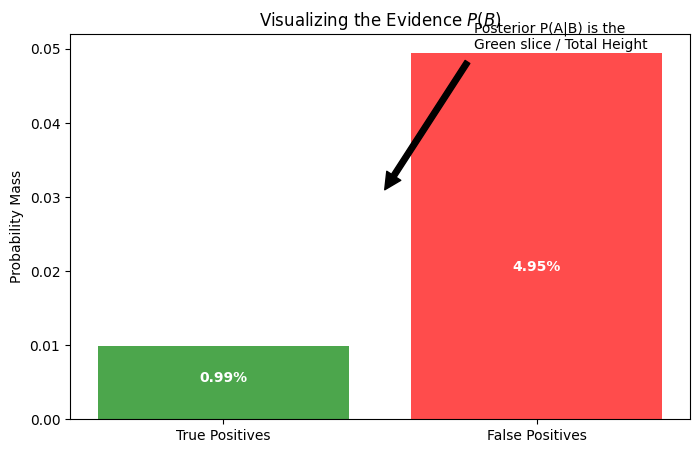

Total Positive Rate P(B): 5.94%
Final Probability P(A|B): 16.67%


In [7]:
import matplotlib.pyplot as plt

# Data
labels = ['True Positives', 'False Positives']
counts = [0.0099, 0.0495] # These sum to P(B)

plt.figure(figsize=(8, 5))
plt.bar(labels, counts, color=['green', 'red'], alpha=0.7)

plt.title("Visualizing the Evidence $P(B)$")
plt.ylabel("Probability Mass")
plt.text(0, 0.005, f"{counts[0]*100:.2f}%", ha='center', color='white', fontweight='bold')
plt.text(1, 0.02, f"{counts[1]*100:.2f}%", ha='center', color='white', fontweight='bold')

plt.annotate('Posterior P(A|B) is the \nGreen slice / Total Height',
             xy=(0.5, 0.03), xytext=(0.8, 0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()

print(f"Total Positive Rate P(B): {sum(counts)*100:.2f}%")
print(f"Final Probability P(A|B): {(counts[0]/sum(counts))*100:.2f}%")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(6, 6))

# Representing the Sample Space
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.add_patch(plt.Rectangle((0,0), 10, 10, color='whitesmoke', label='Sample Space $\\Omega$'))

# Draw Event B
circle_b = Circle((6, 5), 3, color='blue', alpha=0.3, label='Event B')
ax.add_patch(circle_b)

# Draw Event A
circle_a = Circle((4, 5), 3, color='red', alpha=0.3, label='Event A')
ax.add_patch(circle_a)

# Highlight Intersection A \cap B
plt.text(5, 5, "$A \\cap B$", fontsize=12, fontweight='bold', ha='center')
plt.text(2, 5, "A", fontsize=12, ha='center')
plt.text(8, 5, "B", fontsize=12, ha='center')

plt.title("Conditional Probability $P(A|B)$:\nWhat fraction of B is covered by A?")
plt.legend(loc='upper right')
ax.set_aspect('equal')
plt.axis('off')
plt.show()

## 3.3 The Measure-Theoretic Definition

Let $(\Omega, \mathfrak{A}, P)$ be a probability space. Let $A \in \mathfrak{A}$ be an event (where $P(A) > 0$) and $\mathfrak{F}$ be a sub-$\sigma$-algebra of $\mathfrak{A}$.

The most rigorous way to define Bayes' Theorem is through the **Conditional Expectation** of an indicator function. However, for the specific case of two events or two random variables, we define it as follows:

### 1. For Events (Disintegration of Measure)

Given a partition of the sample space $\Omega = \bigcup_{i} A_i$ into disjoint measurable sets $\{A_i\}$, for any event $B \in \mathfrak{A}$ with $P(B) > 0$, the probability of $A_j$ given $B$ is:

$$P(A_j | B) = \frac{P(B | A_j) P(A_j)}{\int_{\Omega} P(B | A(\omega)) \, dP(\omega)}$$

In the denominator, we see the **Lebesgue integral** over the whole space, which represents the **Total Probability** (the measure of $B$).

### 2. Through the Radon-Nikodym Derivative

In advanced statistical learning, we treat the **Posterior** as a new probability measure $Q$ that is "absolutely continuous" with respect to the **Prior** measure $P$.

If $P$ is our prior measure on the parameter space $\Theta$, and we observe data $x$, the posterior measure $P_{X=x}$ is defined such that its density with respect to the prior is proportional to the likelihood:

$$\frac{dP_{\theta|x}}{dP_{\theta}}(\theta) = \frac{f(x|\theta)}{\int_{\Theta} f(x|\theta') \, dP(\theta')}$$

> **What this means:** The "update" from prior to posterior is essentially a **change of measure**. We are re-weighting the original probability mass $(dP)$ using the likelihood function $f(x|\theta)$ as the scaling factor.

---

## 12.1 The Four Components

| Term | Symbol | Measure-Theoretic Role |
| --- | --- | --- |
| **Prior** | $P(\theta)$ | The base probability measure on the parameter space. |
| **Likelihood** | $P(D | \theta)$ |
| **Evidence** | $P(D)$ | The normalizing constant (Total Measure of the data). |
| **Posterior** | $P(\theta | D)$ |

---

## 12.2 Visualizing the Measure Change

To help your students understand, think of the **Prior** as a uniform distribution of "clay" over a table. The **Likelihood** acts as a "mold" that pushes the clay into a specific shape based on the data. The resulting shape is the **Posterior**.

/tmp/ipykernel_398/644054522.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  posterior = unnormalized_posterior / np.trapz(unnormalized_posterior, theta)


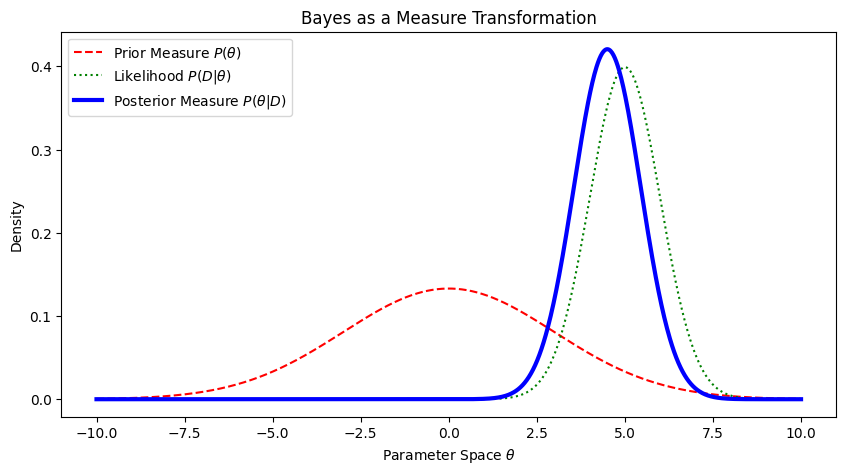

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Define the Prior Measure (Broad/Uncertain)
theta = np.linspace(-10, 10, 1000)
prior = norm.pdf(theta, loc=0, scale=3)

# 2. Define the Likelihood (Data suggests theta is near 5)
# Let's say we observed a data point x=5 with some noise
likelihood = norm.pdf(theta, loc=5, scale=1)

# 3. Compute Posterior (Element-wise product + Normalization)
unnormalized_posterior = likelihood * prior
posterior = unnormalized_posterior / np.trapz(unnormalized_posterior, theta)

plt.figure(figsize=(10, 5))
plt.plot(theta, prior, 'r--', label='Prior Measure $P(\\theta)$')
plt.plot(theta, likelihood, 'g:', label='Likelihood $P(D|\\theta)$')
plt.plot(theta, posterior, 'b-', lw=3, label='Posterior Measure $P(\\theta|D)$')

plt.title("Bayes as a Measure Transformation")
plt.xlabel("Parameter Space $\\theta$")
plt.ylabel("Density")
plt.legend()
plt.show()